# Single-Cell Analysis of the Breast Cancer Tumor Microenvironment

This notebook covers loading, quality control, and clustering of the Wu et al. 2021 breast cancer scRNA-seq atlas (GSE176078 / CELLxGENE), as a single-cell extension of an earlier bulk RNA-seq analysis of Basal vs. Luminal breast cancer subtypes. The bulk work found a mitotic/cell-cycle signature enriched in the more aggressive subtype, but bulk data averages across every cell in a tumor sample, so it can't distinguish a genuinely malignant-cell-intrinsic effect from a difference in tumor composition. That question is what this larger single-cell project is built to answer, and this first notebook lays the groundwork: a clean, correctly-processed, clustered dataset to build the rest of the analysis on.

## Environment

Working in Google Colab against data stored on Drive, so the project directory is set up first and reused across the whole notebook.

In [1]:
import os

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = "/content/drive/MyDrive/single-cell-breast-cancer-project"
else:
    PROJECT_DIR = "."

DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Data directory:", DATA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/single-cell-breast-cancer-project/data


Package installation for the single-cell stack — scanpy as the core toolkit, plus celltypist, harmonypy, and the clustering dependencies used later on.

In [ ]:
!pip install scanpy anndata celltypist harmonypy gseapy scikit-learn scrublet leidenalg igraph

In [5]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Getting the data

The full atlas (all patients, all cell types) is what's needed here, not one of CELLxGENE's pre-split subsets — the tumor microenvironment composition question later in this project needs every cell type present together, and the malignant-cell question needs the epithelial compartment intact rather than split off.

In [7]:
import os, requests

url = "https://datasets.cellxgene.cziscience.com/22a27631-aecf-463b-86c6-a8334a2f2cf2.h5ad"
output_path = os.path.join(DATA_DIR, "wu2021_breast_cancer.h5ad")

print("Downloading to:", output_path)
response = requests.get(url, stream=True)
response.raise_for_status()

total = int(response.headers.get('content-length', 0))
downloaded = 0
with open(output_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        f.write(chunk)
        downloaded += len(chunk)
        if total:
            print(f"\r{downloaded/(1024*1024):.1f} / {total/(1024*1024):.1f} MB", end="")

print("\nDone.")


804.8 / 804.8 MB
Done.


Loading the file and taking a first look at the structure before doing anything else with it.

In [11]:
DATA_PATH = os.path.join(DATA_DIR, "wu2021_breast_cancer.h5ad")
assert os.path.exists(DATA_PATH), (
f"Can't find {DATA_PATH} — go get it from CELLxGENE or GEO first (see above)."
)
adata = sc.read_h5ad(DATA_PATH)
print(adata)

AnnData object with n_obs × n_vars = 100064 × 28468
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'is_pre_analysis', 'organism', 'organism

Before trusting `.X` as the working expression matrix, it's worth checking what's actually in it. CELLxGENE objects commonly ship `.X` already normalized, with raw counts held separately in `.raw` — worth confirming rather than assuming, since the whole QC and normalization pipeline downstream depends on starting from real counts.

In [12]:
print("adata.X range:", adata.X.min(), adata.X.max())
print("Has .raw:", adata.raw is not None)
if adata.raw is not None:
    print("adata.raw.X range:", adata.raw.X.min(), adata.raw.X.max())

print(adata.var[['feature_name']].head())
print("var_names sample:", adata.var_names[:5].tolist())


adata.X range: 0.0 9.111652
Has .raw: True
adata.raw.X range: 0.0 29831.0
                    feature_name
ENSG00000279928         DDX11L17
ENSG00000279457           WASH9P
ENSG00000228463  ENSG00000228463
ENSG00000237094  ENSG00000237094
ENSG00000230021  ENSG00000230021
var_names sample: ['ENSG00000279928', 'ENSG00000279457', 'ENSG00000228463', 'ENSG00000237094', 'ENSG00000230021']


Confirmed: `.X` here is already log-normalized (values capped under 10), and the real raw counts live in `.raw.X` — the actual counts, un-transformed, exactly as expected. Gene identifiers are Ensembl IDs rather than gene symbols too, which will be a problem later for mitochondrial gene detection (that relies on the `MT-` symbol prefix), so both things get fixed at once: switch to the raw counts, and swap the gene index over to symbols, keeping the Ensembl ID around as a backup column.

In [13]:
# Switch from normalized .X to the raw counts + full gene set stored in .raw
adata = adata.raw.to_adata()

# Swap var_names from Ensembl IDs to gene symbols, keeping the Ensembl ID
# as a backup column in case we need it later
adata.var["ensembl_id"] = adata.var_names
adata.var_names = adata.var["feature_name"].astype(str)
adata.var_names_make_unique()

print("New shape:", adata.shape)
print("X range:", adata.X.min(), adata.X.max())
print("var_names sample:", adata.var_names[:10].tolist())
print("MT genes found:", adata.var_names.str.startswith("MT-").sum())


New shape: (100064, 28468)
X range: 0.0 29831.0
var_names sample: ['DDX11L17', 'WASH9P', 'ENSG00000228463', 'ENSG00000237094', 'ENSG00000230021', 'LINC01409', 'LINC00115', 'FAM41C', 'LINC02593', 'SAMD11']
MT genes found: 13


Both fixes worked — the mitochondrial gene count came back at 13, which is the expected number for a human dataset, a good sanity check that the symbol swap did what it was supposed to.

## Quality control

Standard scRNA-seq QC: flag mitochondrial genes, then compute the three per-cell metrics that matter most — total UMI counts, number of genes detected, and the fraction of counts coming from mitochondrial genes. High mitochondrial fraction is the most reliable signal of a dying or lysed cell, since mitochondria are membrane-bound and leak less of their contents than the rest of the cytoplasm during cell death.

In [14]:
# Officially flag mitochondrial genes (Already confirmed this finds 13 above)
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate per-cell QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

print(adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe())


       n_genes_by_counts   total_counts  pct_counts_mt
count      100064.000000  100064.000000  100064.000000
mean         1772.656190    7125.463379       6.085261
std          1339.605016    9930.953125       3.971097
min           199.000000     250.000000       0.000000
25%           816.000000    1918.000000       3.187200
50%          1335.500000    3564.000000       5.156137
75%          2327.000000    7947.000000       8.115371
max         10274.000000  181422.000000      20.626631


The summary statistics alone don't tell the whole story — a violin or scatter plot can reveal a bimodal distribution or a clear "elbow" that isn't obvious from percentiles. Plotting before deciding on any filtering thresholds, rather than copying a threshold from a tutorial and hoping it fits this dataset.

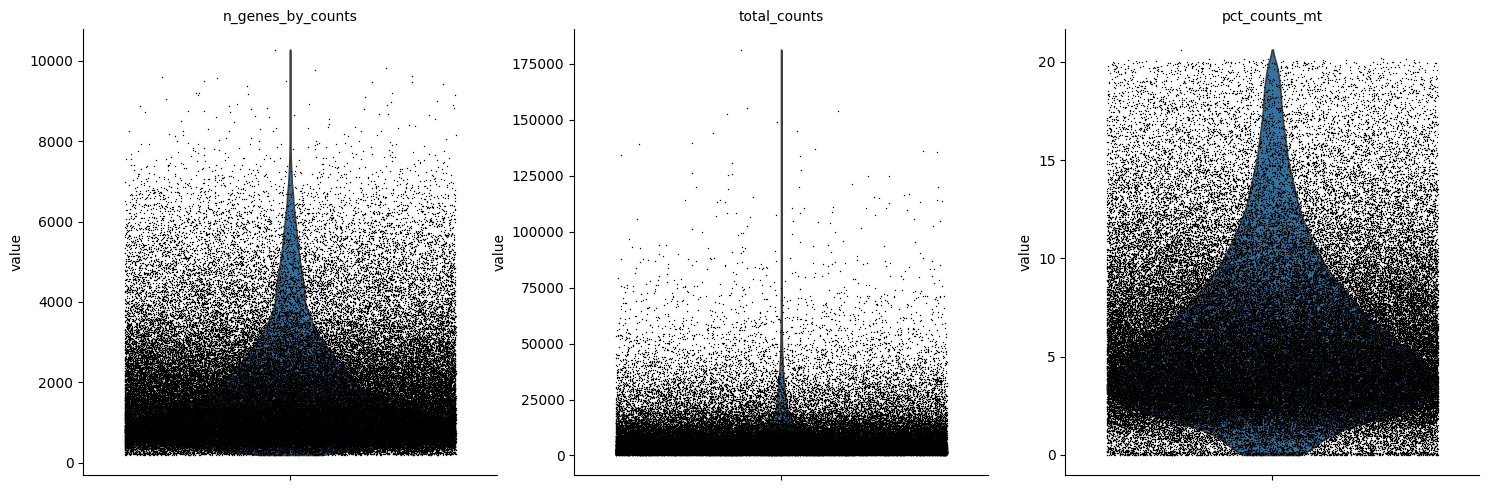

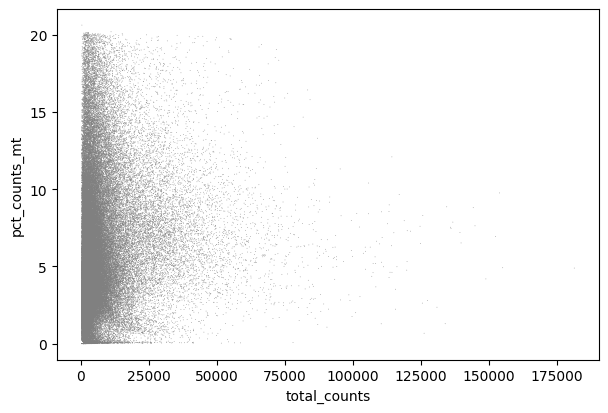

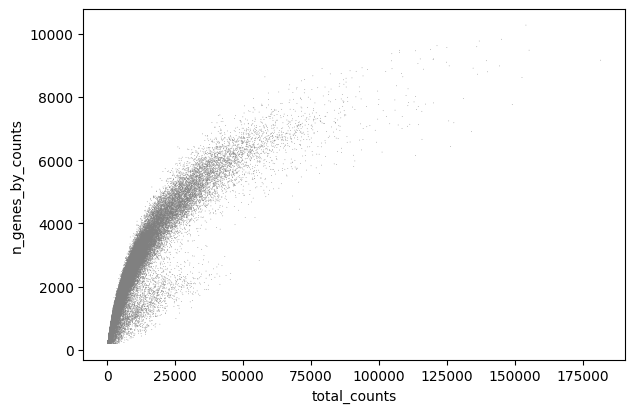

In [15]:
axes = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)
axes.figure.savefig(f"{FIG_DIR}/qc_violin.png", dpi=150, bbox_inches="tight")

ax = sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False)
ax.figure.savefig(f"{FIG_DIR}/qc_counts_vs_mt.png", dpi=150, bbox_inches="tight")

ax2 = sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False)
ax2.figure.savefig(f"{FIG_DIR}/qc_counts_vs_genes.png", dpi=150, bbox_inches="tight")


The distributions turned out fairly clean — no dramatic low-quality tail demanding an aggressive cutoff. That's not too surprising: this is a published, curated atlas, and the original authors likely already ran their own QC pass before depositing it. Given that, fairly lenient thresholds seemed like the right call rather than being unnecessarily aggressive on data that's probably already reasonably clean: `min_genes=200` (matches the natural floor in the data), `total_counts<=50000` (about 6x the 75th percentile, only trimming the most extreme outliers), and `pct_counts_mt<=20` (barely below the observed maximum, appropriate for tumor tissue which legitimately runs a bit higher mitochondrial fraction than healthy tissue).

In [16]:
n_before = adata.n_obs
adata = adata[adata.obs.n_genes_by_counts >= 200, :]
adata = adata[adata.obs.total_counts <= 50000, :]
adata = adata[adata.obs.pct_counts_mt <= 20, :]
print(f"Cells before filtering: {n_before}")
print(f"Cells after filtering: {adata.n_obs}")
print(f"Removed: {n_before - adata.n_obs} ({100*(n_before-adata.n_obs)/n_before:.1f}%)")


Cells before filtering: 100064
Cells after filtering: 99084
Removed: 980 (1.0%)


Only about 1% of cells removed — consistent with the read on the QC plots that this data didn't need heavy filtering.

## Doublet detection

Scrublet flags likely doublets — droplets that captured two cells instead of one — by simulating synthetic doublets from the data itself and scoring how similar each real cell looks to those simulants. Run with `batch_key="donor_id"` rather than on the pooled dataset: doublets form within a single 10x run, so simulating them by randomly pairing cells across *different* patients would create biologically meaningless combinations. Scrublet is designed to run per-sample for exactly this reason, and doing it per-donor here also keeps each individual computation small, which matters given the size of this dataset.

In [17]:
sc.pp.scrublet(adata, batch_key="donor_id")

print(adata.obs["predicted_doublet"].value_counts())
print("\nDoublet score distribution:")
print(adata.obs["doublet_score"].describe())


Running Scrublet
filtered out 10945 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:05)
extracting highly variable genes
    finished (0:00:03)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.56
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 3.4%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.9%
filtered out 9715 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.34
Detected doublet rate = 0.1%
Estimated detectable doublet 

Before trusting the automated doublet calls, it's worth checking what threshold Scrublet actually landed on and what the underlying score distributions look like — a threshold that seems reasonable in isolation might still reflect poor separation between real cells and simulated doublets if the two distributions overlap heavily.

Effective threshold used: 0.2500000000000001


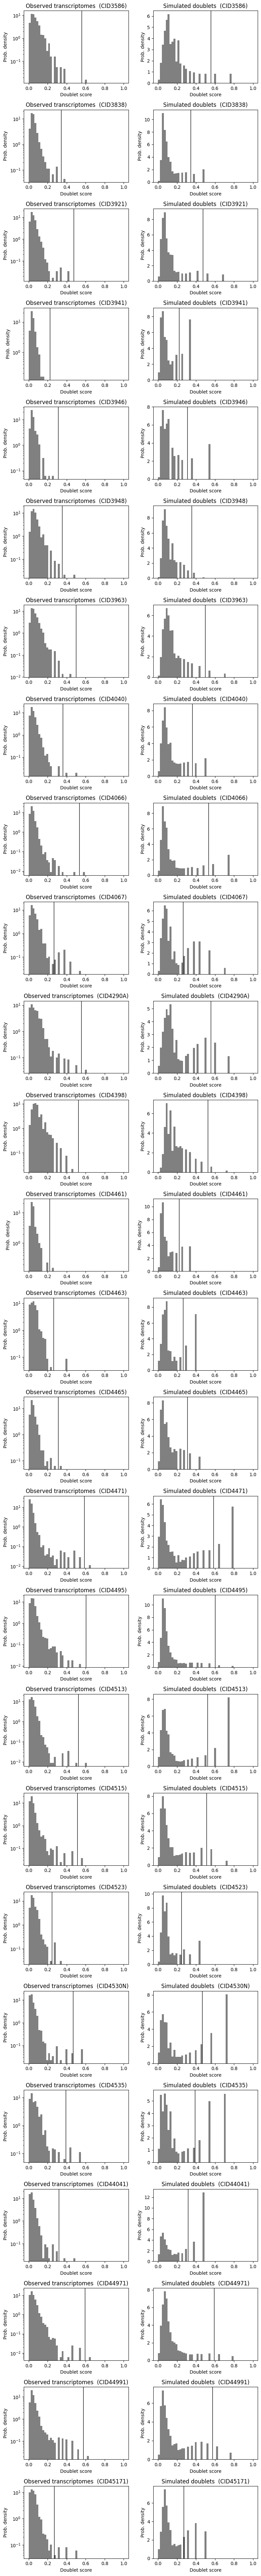

In [18]:
# What threshold did Scrublet actually pick?
threshold_used = adata.obs.loc[adata.obs['predicted_doublet'], 'doublet_score'].min()
print("Effective threshold used:", threshold_used)

# Visualize it directly — shows real-cell scores vs. simulated-doublet scores side by side
sc.pl.scrublet_score_distribution(adata)


The threshold (0.25) sits in a sensible range, and the per-donor score distributions (plotted above, observed cells vs. simulated doublets side by side) show enough separation to trust the automated call. Worth noting: this dataset's authors likely already ran their own QC/doublet handling before deposit — evidenced by the `normal_cell_call` and `CNA_value` fields already present in `.obs` — so finding a fairly low number of *additional* doublets on a second pass is consistent with that, not a sign anything is miscalibrated.

In [19]:
n_before = adata.n_obs
adata = adata[~adata.obs["predicted_doublet"]].copy()
print(f"Removed {n_before - adata.n_obs} predicted doublets ({n_before} -> {adata.n_obs})")

adata.var.index.name = None  # avoid name collision with the 'feature_name' column

adata.write(os.path.join(DATA_DIR, "adata_qc_checkpoint.h5ad"))
print("Saved checkpoint to", os.path.join(DATA_DIR, "adata_qc_checkpoint.h5ad"))


Removed 120 predicted doublets (99084 -> 98964)
Saved checkpoint to /content/drive/MyDrive/single-cell-breast-cancer-project/data/adata_qc_checkpoint.h5ad


## Normalization, dimensionality reduction, and batch correction

Picking back up from the saved checkpoint. Loading fresh here rather than continuing in the same session keeps memory usage predictable — this dataset is large enough that keeping every intermediate object alive across the whole pipeline isn't necessary and isn't free.

In [8]:
sc.settings.verbosity = 2
sc.settings.figdir = FIG_DIR  # reuses the FIG_DIR variable from Part 1's Drive-mount cell

adata = sc.read_h5ad(os.path.join(DATA_DIR, "adata_qc_checkpoint.h5ad"))
print(adata)

AnnData object with n_obs × n_vars = 98964 × 28468
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'feature_name', 'feature_reference', 'feature_biotyp

26 donors, three molecular subtypes (TNBC / ER+ / HER2+), and the nine broad cell-type categories the original authors annotated. Good to have these numbers in hand before going further — they come back into play later when this same subtype breakdown is used to compare TNBC vs. ER+ tumors specifically.

In [9]:
assert adata.X.min() >= 0, "Expected non-negative raw counts here — something's off if this fails"
print("\nDonors:", adata.obs["donor_id"].nunique())
print("Subtypes:", adata.obs["subtype"].value_counts())
print("Cell types (major):", adata.obs["celltype_major"].value_counts())



Donors: 26
Subtypes: subtype
TNBC     42082
ER+      37929
HER2+    18953
Name: count, dtype: int64
Cell types (major): celltype_major
T-cells              35187
Cancer Epithelial    23794
Myeloid               9529
Endothelial           7562
CAFs                  6529
PVL                   5373
Normal Epithelial     4268
Plasmablasts          3521
B-cells               3201
Name: count, dtype: int64


Standard log-normalization to 10,000 counts per cell (matching what most pretrained tools, including CellTypist later on, expect as input).

In [10]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("Normalization done. X range now:", adata.X.min(), adata.X.max())


normalizing counts per cell
    finished (0:00:05)
Normalization done. X range now: 0.0 9.111652


Selecting highly variable genes with `batch_key="donor_id"` rather than treating the pooled dataset as one batch — without this, "highly variable" risks just meaning "differs a lot between patients" rather than "varies due to real cell-type biology." Computing variability within each donor separately and keeping genes that are consistently informative across donors is the more defensible choice here, especially with 26 donors in the mix.

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor_id")
print("Highly variable genes selected:", adata.var["highly_variable"].sum())


extracting highly variable genes
    finished (0:00:21)
Highly variable genes selected: 2000


PCA is run on a separate, HVG-only copy of the data rather than the full ~28,000-gene object. This isn't just about computation time — `sc.pp.scale()`, which PCA needs, mean-centers the data, and mean-centering a sparse matrix forces it to densify. At the full gene count and this many cells, that dense matrix would be large enough to be a genuine memory concern; restricting to the ~2,000 HVGs first keeps it manageable, with no change to the actual result, since scaling is a per-gene operation unaffected by which other genes happen to be in the matrix. The PCA coordinates are copied back onto the main object afterward and the temporary HVG copy is discarded.

In [12]:
import gc

adata_hvg = adata[:, adata.var["highly_variable"]].copy()
print("HVG-only object for PCA:", adata_hvg.shape)

sc.pp.scale(adata_hvg, max_value=10)
sc.pp.pca(adata_hvg, n_comps=50)

adata.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
del adata_hvg
gc.collect()  # explicitly reclaim that memory now, don't wait for Python to get to it

print("PCA done. Shape:", adata.obsm["X_pca"].shape)


HVG-only object for PCA: (98964, 2000)


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50
    finished (0:00:57)
PCA done. Shape: (98964, 50)


## Batch correction

With 26 donors — different patients, different processing days, different everything technical — some separation in PCA space is expected purely from batch effects rather than real biology. Left uncorrected, two T cells from different patients could end up further apart in PCA space than a T cell and a macrophage from the *same* patient, which would badly confound any downstream clustering. Harmony corrects for this while (in principle) preserving genuine biological differences between patients.

Harmony is called directly via `harmonypy` rather than through scanpy's `sc.external.pp.harmony_integrate()` wrapper — a version mismatch between the currently available scanpy and harmonypy otherwise throws a shape error. Calling the underlying library directly sidesteps it.

In [13]:
ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs, ["donor_id"])
adata.obsm["X_pca_harmony"] = np.asarray(ho.Z_corr)  # no transpose needed in harmonypy>=2.0

print("Harmony batch correction done. Shape:", adata.obsm["X_pca_harmony"].shape)


2026-08-11 11:57:51,642 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-08-11 11:57:51,644 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-08-11 11:57:51,646 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-08-11 11:57:51,648 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-08-11 11:57:51,650 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-08-11 11:57:51,652 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-08-11 11:57:51,654 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-08-11 11:57:51,655 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-08-11 11:57:51,657 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-08-11 11:57:51,659 - harmonypy - INFO -     theta: [2. 2. 2

Harmony batch correction done. Shape: (98964, 50)


Converged after 6 iterations, which is a reasonable number — didn't run out the full 10 without converging, which would have been a mild yellow flag.

## Clustering and visualization

Neighbors and Leiden clustering are computed on the harmony-corrected representation, not the raw PCA — clustering before batch correction would risk clusters forming around donor identity rather than cell type, which would defeat the point of correcting for it in the first place.

In [14]:
sc.pp.neighbors(adata, use_rep="X_pca_harmony")
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2)

print("Leiden clustering done. Clusters found:", adata.obs["leiden"].nunique())
print(adata.obs["leiden"].value_counts())


computing neighbors
    finished (0:01:34)
running Leiden clustering
    finished (0:00:07)
Leiden clustering done. Clusters found: 30
leiden
12    11890
14    11774
22    10291
21     9126
4      7063
8      6905
2      5471
18     4747
0      4000
1      3579
25     3228
6      3122
23     2961
13     2825
10     2533
15     2231
7      2180
11     1204
16     1171
5      1133
28      616
20      403
17      295
27       92
26       29
9        25
3        21
29       20
24       16
19       13
Name: count, dtype: int64


30 clusters at this resolution — considerably more granular than the 9 broad cell-type categories from the original annotation, which makes sense: T cells, myeloid cells, and epithelial cells are each themselves mixtures of finer subpopulations that Leiden is free to split apart.

computing UMAP
    finished (0:02:32)


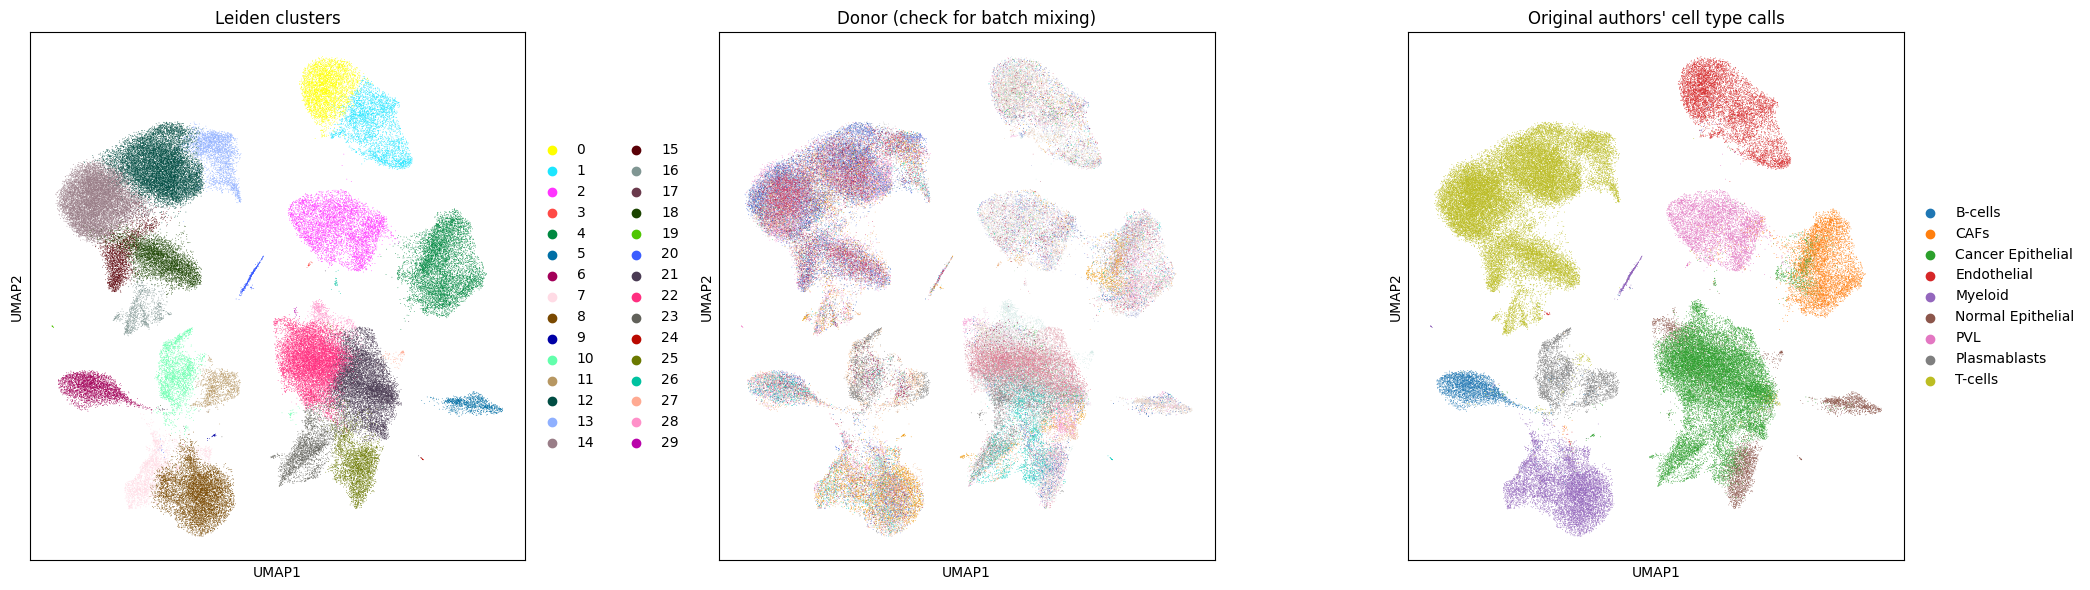

Saved umap_overview.png


In [15]:
sc.tl.umap(adata)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title="Leiden clusters")
sc.pl.umap(adata, color="donor_id", ax=axes[1], show=False, title="Donor (check for batch mixing)", legend_loc=None)
sc.pl.umap(adata, color="celltype_major", ax=axes[2], show=False, title="Original authors' cell type calls")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "umap_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Saved umap_overview.png")


The three-panel view is the useful sanity check here: Leiden clusters (left) should form visually distinct groups, donor identity (middle) should look well-mixed *within* each cluster rather than showing visible per-patient sub-blobs (the actual test of whether Harmony did its job), and the original authors' cell-type calls (right) should broadly align with the cluster boundaries. All three look right — clusters subdivide *within* each cell-type region rather than spanning across clearly different lineages, and the donor panel shows the speckled mixing pattern that indicates batch correction worked rather than leaving patient identity as the dominant signal.

In [16]:
adata.raw = adata

adata.write(os.path.join(DATA_DIR, "adata_clustered_checkpoint.h5ad"))
print("Saved checkpoint to", os.path.join(DATA_DIR, "adata_clustered_checkpoint.h5ad"))

Saved checkpoint to /content/drive/MyDrive/single-cell-breast-cancer-project/data/adata_clustered_checkpoint.h5ad


## A closer look at the smallest clusters

A few of the 30 clusters are very small, and one in particular showed up as a thin, isolated sliver in the UMAP rather than a normal-looking blob — worth checking before treating the clustering as done, since small isolated clusters can be either genuine rare populations or leftover technical artifacts that Harmony had no way to fix (it can only align populations that exist across multiple donors).

In [17]:
print(adata.obs.groupby("leiden")["donor_id"].nunique())  # is it basically one donor?
print(adata.obs["leiden"].value_counts().tail(5))          # how many cells is it?


leiden
0     25
1     26
2     26
3      1
4     26
5     13
6     20
7     26
8     26
9      2
10    24
11    14
12    26
13    26
14    26
15    26
16    22
17    22
18    26
19     1
20    26
21    23
22    21
23    20
24     1
25    19
26     6
27     1
28    10
29     1
Name: donor_id, dtype: int64
leiden
9     25
3     21
29    20
24    16
19    13
Name: count, dtype: int64


In [18]:
pd.crosstab(adata.obs["leiden"], adata.obs["celltype_major"])


celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
leiden,,,,,,,,,
0,3,5,3,3959,25,0,0,0,5
1,0,0,3,3555,9,0,10,0,2
2,0,155,23,6,0,0,5283,0,4
3,0,1,0,0,0,0,20,0,0
4,0,6341,661,2,2,0,51,0,6
5,0,0,22,0,0,1103,3,2,3
6,3064,0,8,0,27,0,0,2,21
7,18,0,1,0,2156,0,0,1,4
8,25,1,9,19,6840,0,0,0,11


In [19]:
small_clusters = ["3", "9", "19", "24", "27", "29"]
for cl in small_clusters:
    print(f"\nCluster {cl}:")
    print(adata.obs.loc[adata.obs["leiden"] == cl, "celltype_major"].value_counts())



Cluster 3:
celltype_major
PVL                  20
CAFs                  1
B-cells               0
Cancer Epithelial     0
Endothelial           0
Myeloid               0
Normal Epithelial     0
Plasmablasts          0
T-cells               0
Name: count, dtype: int64

Cluster 9:
celltype_major
Cancer Epithelial    24
Myeloid               1
B-cells               0
CAFs                  0
Endothelial           0
Normal Epithelial     0
PVL                   0
Plasmablasts          0
T-cells               0
Name: count, dtype: int64

Cluster 19:
celltype_major
Myeloid              13
B-cells               0
CAFs                  0
Cancer Epithelial     0
Endothelial           0
Normal Epithelial     0
PVL                   0
Plasmablasts          0
T-cells               0
Name: count, dtype: int64

Cluster 24:
celltype_major
Normal Epithelial    16
B-cells               0
CAFs                  0
Cancer Epithelial     0
Endothelial           0
Myeloid               0
PVL                 

Clusters 3, 9, 19, 24, and 27 are each confined to a single donor, and cluster 29 to what's almost certainly one patient's epithelial compartment. On its own that would be a reasonable flag for a technical artifact — except every one of these came back as a *clean, single, plausible cell type* rather than a mix of unrelated ones (PVL, Cancer Epithelial, Myeloid, Normal Epithelial x2, Normal+Cancer Epithelial), which is the opposite of what a technical artifact usually looks like.

There's also a real biological reason to expect this specifically in the epithelial clusters (4 of the 6): malignant epithelial cells carry patient-specific copy-number alterations and driver mutations — actual genomic differences, not batch noise. Harmony can only align signal that's shared *across* donors; a real, patient-specific tumor genotype has nothing to align to, so it's expected to remain somewhat separate even after correction. This is consistent with why the dataset ships `CNA_value` and `normal_cell_call` fields in the first place. Together these six clusters account for under 0.2% of all cells, so whether they're kept or dropped has essentially no effect on anything downstream — leaving them in seemed like the more defensible choice given how clean and biologically plausible each one looks individually.